# Some exploratory data anaylisis, to check that the normalisation is working

In [1]:
import torch
from torch.utils.data import DataLoader

from src import video_transforms as vt
from src.configs import get_avail_splits, get_class_list, set_seed
from src.models import avail_models, norm_vals
from src.run_types import (
    AVAIL_SPLITS,
    SEED,
    CentreCropConfig,
    OG_Sampler,
    RandomCropConfig,
)
from src.utils import plt_display
from src.video_dataset import VideoDataset, get_transform, get_wlasl_info
from src.visualise2 import set_thesis_style

In [2]:
set_thesis_style()
set_seed(SEED)

## Setup

### Model

Available models:

In [3]:
av_models = avail_models()
for idx, m in enumerate(av_models):
    print(f"{idx}: {m}")

0: S3D
1: R3D_18
2: R(2+1)D_18
3: Swin3D_T
4: Swin3D_S
5: Swin3D_B
6: MViTv2_S
7: MViTv2_S_e
8: MViTv1_B
9: MViTv2_S_16x4
10: MViTv2_S_16x4_e
11: MViTv2_B_32x3
12: MViTv2_B_32x3_r


Chosen model: 

In [4]:
model_name = "MViTv1_B"
print(model_name)

MViTv1_B


Norm values: 

In [5]:
model_info = norm_vals(model_name)
print(model_info)

mean=(0.45, 0.45, 0.45) std=(0.225, 0.225, 0.225)


### Dataset

Available splits

In [6]:
av_splits = get_avail_splits()
for s in av_splits:
    print(s)

asl100_worst
asl1000
asl2000_cutoff_9
asl100_bottom
asl100
asl300_cutoff_9
asl1000_cutoff_9
asl2000
asl100_cutoff_9
asl300


Chosen split, and set

In [7]:
split_name: AVAIL_SPLITS = "asl100"
print(split_name)

asl100


Dataset info

In [8]:
train_info = get_wlasl_info(split_name, set_name="train")
print(train_info)


{'root': PosixPath('/home/luke/Code/SLR/data/WLASL/WLASL2000'), 'labels': PosixPath('/home/luke/Code/SLR/data/WLASL/preprocessed/labels/asl100'), 'label_suff': 'fixed_frange_bboxes.json', 'set_name': 'train'}


Class list

In [9]:
class_list = get_class_list()
print(len(class_list))

2000


#### Data Sets

one in regular conditions, and the other 'raw'


In [10]:
norm_dict = norm_vals(model_name)
print(norm_dict)
num_frames = 16
frame_size = 112
batch_size = 1

mean=(0.45, 0.45, 0.45) std=(0.225, 0.225, 0.225)


In [11]:
print(model_info)

mean=(0.45, 0.45, 0.45) std=(0.225, 0.225, 0.225)


In [12]:
train_transform, _, _ = get_transform(
    norm_dict=norm_dict,
    temporal_aug=[OG_Sampler(target_length=num_frames)],
    spatial_aug=[RandomCropConfig(frame_size=frame_size)],
)

test_transform, _, _ = get_transform(
    norm_dict=norm_dict,
    temporal_aug=[OG_Sampler(target_length=num_frames)],
    spatial_aug=[CentreCropConfig(frame_size=frame_size)],
)

train_set = VideoDataset(set_info=train_info, transforms=train_transform)
# same instances as train_set, but centre-cropped instead of randomly cropped
test_set = VideoDataset(set_info=train_info, transforms=test_transform)
# same instances again, bbox-cropped only: no resize/normalise, to see what's lost by the above
raw_set = VideoDataset(set_info=train_info, item_transforms=vt._crop_frames)

In [13]:
train_loader = DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=False,  # not consistent with training, but useful for eda
    num_workers=0,
    pin_memory=False,
)

test_loader = DataLoader(
    test_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

raw_loader = DataLoader(
    raw_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

In [14]:
print(len(train_loader))
print(train_set.num_classes)

1442
100


## Examine frames

In [15]:
iter_train_loader = iter(train_loader)
iter_test_loader = iter(test_loader)
iter_raw_loader = iter(raw_loader)

In [16]:
sample_train = next(iter_train_loader)
sample_test = next(iter_test_loader)
sample_raw = next(iter_raw_loader)


In [17]:
rf = sample_raw['frames']
print(rf.shape)

torch.Size([1, 63, 3, 240, 119])


In [18]:
def prep_frames_and_label(
    sample: dict[str, int | torch.Tensor],
) -> tuple[torch.Tensor, int]:
    frames = sample['frames']
    assert isinstance(frames, torch.Tensor), f'frames is type: {type(frames)}'
    label_num = sample['label_num']
    assert isinstance(label_num, torch.Tensor), f'label num is type: {type(label_num)}'

    if len(frames.shape) == 5:
        frames = frames.squeeze(dim=0)
    if frames.shape[1] != 3:
        frames = frames.permute(1, 0, 2, 3)  # swap T and C
    return frames, int(label_num.squeeze())

# Looking at what the machine sees 
## (training)

frames: torch.Size([16, 3, 112, 112])
Class: book


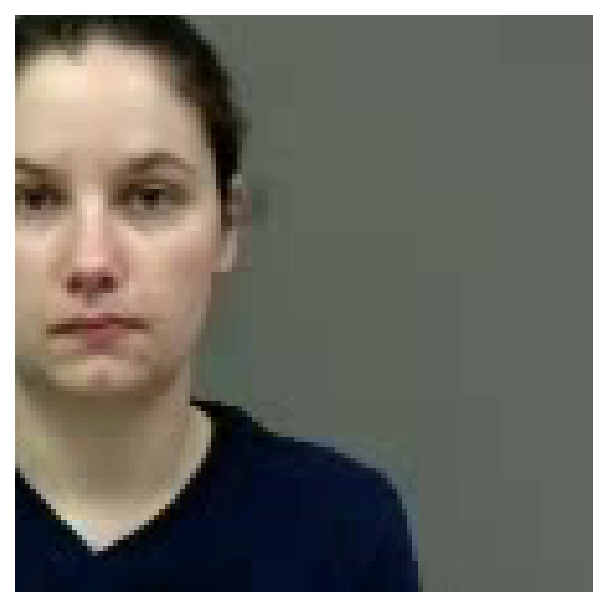

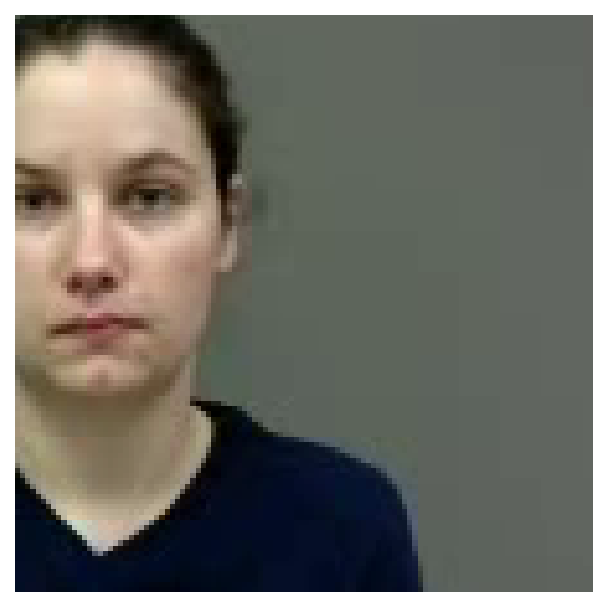

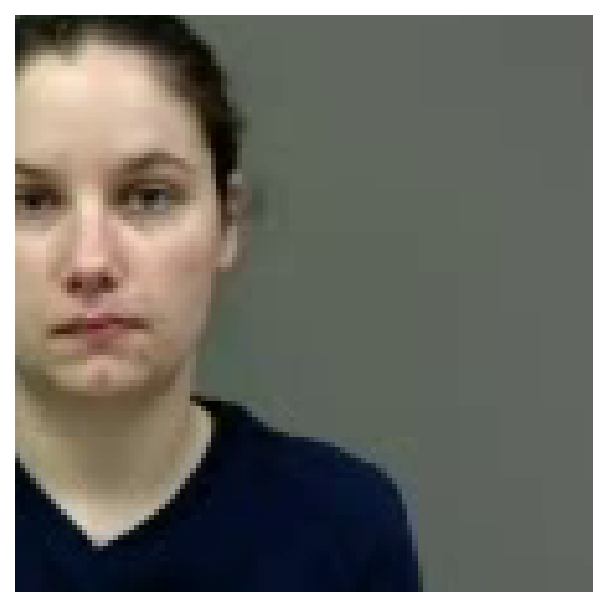

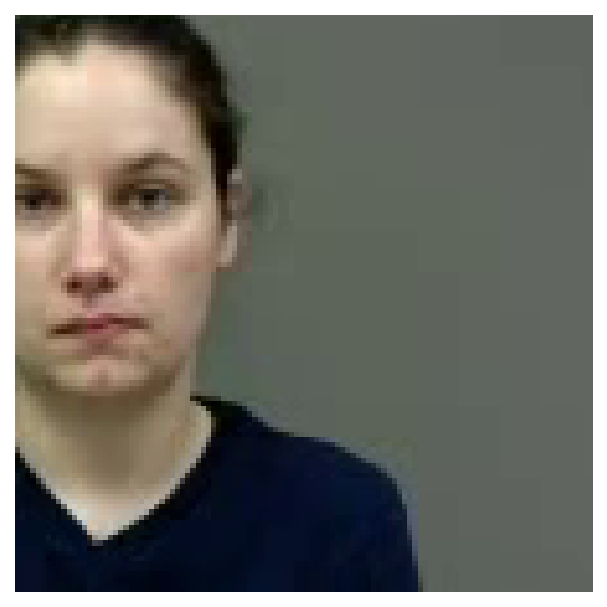

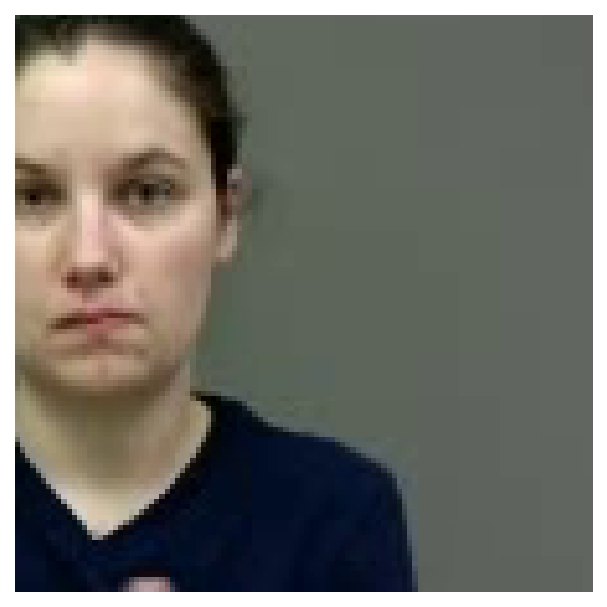

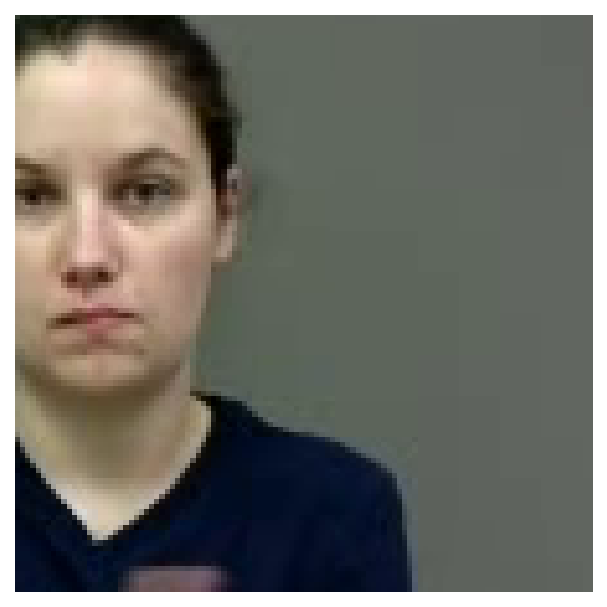

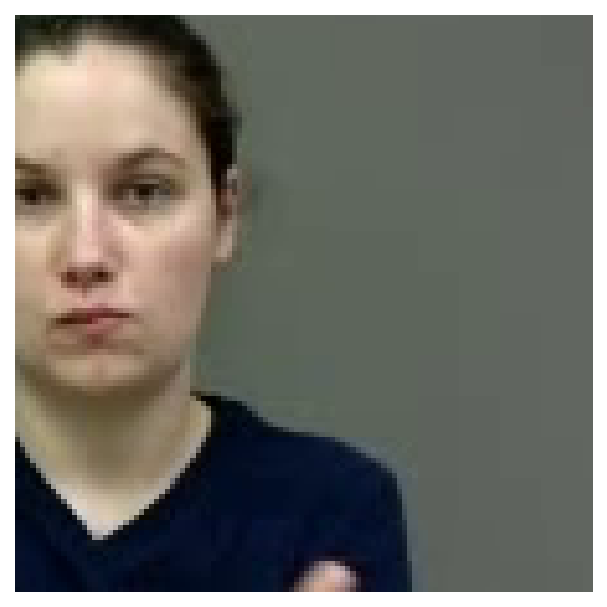

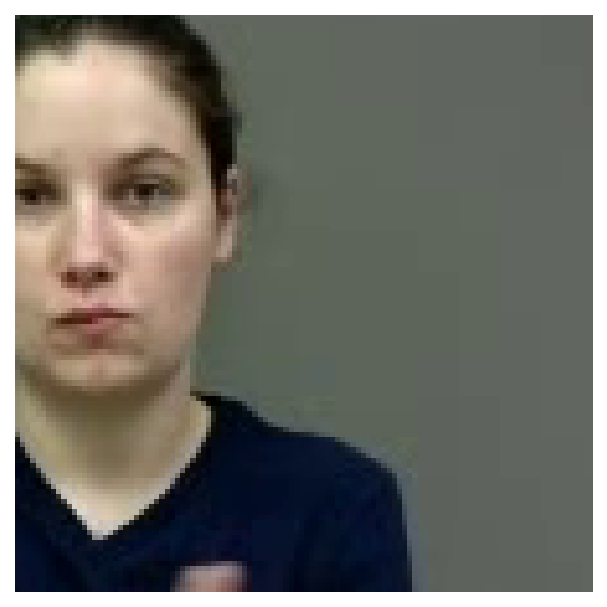

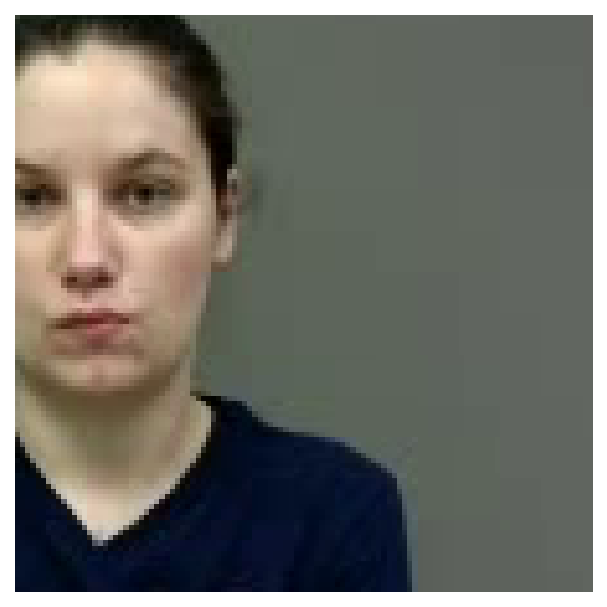

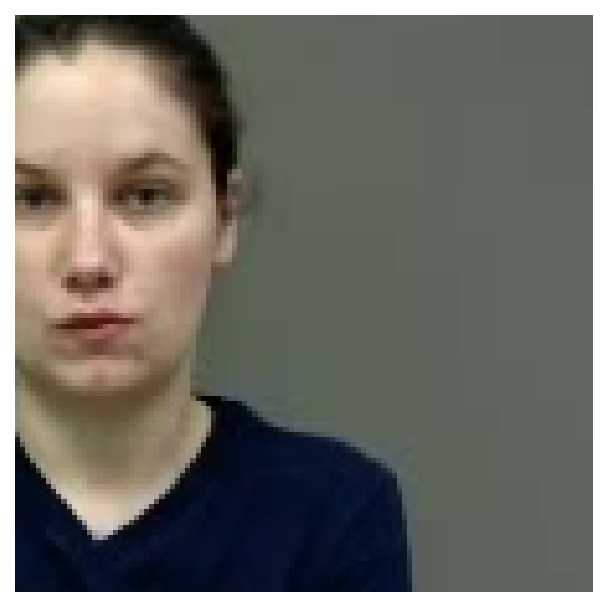

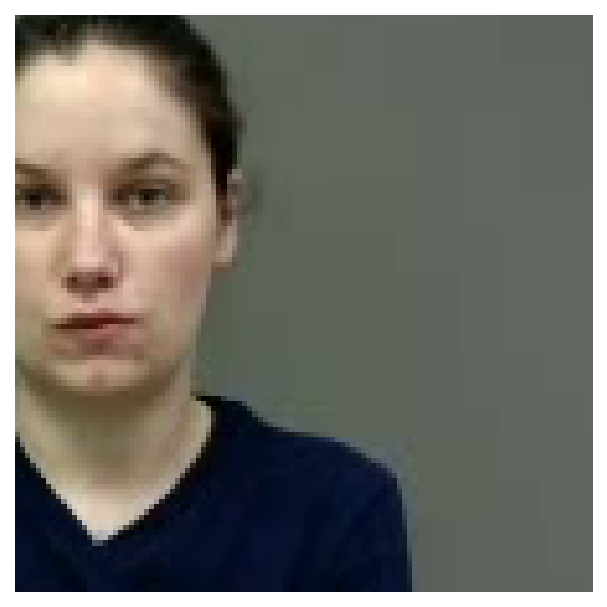

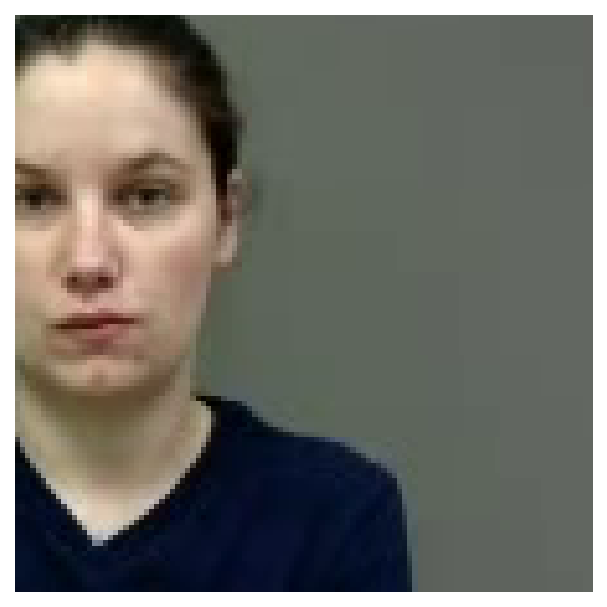

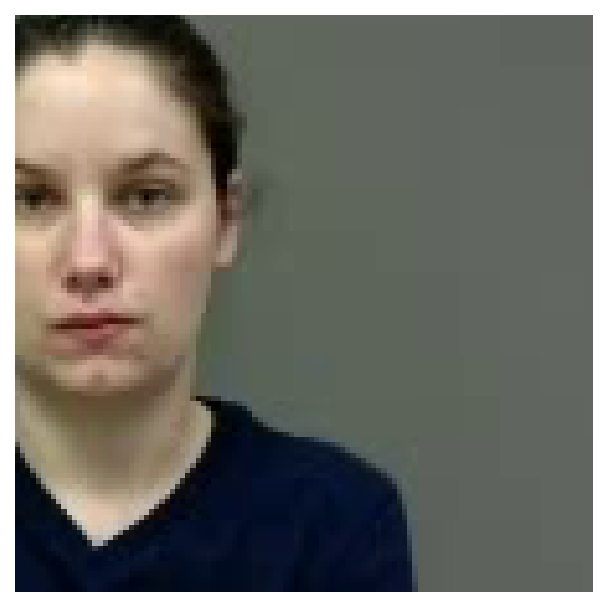

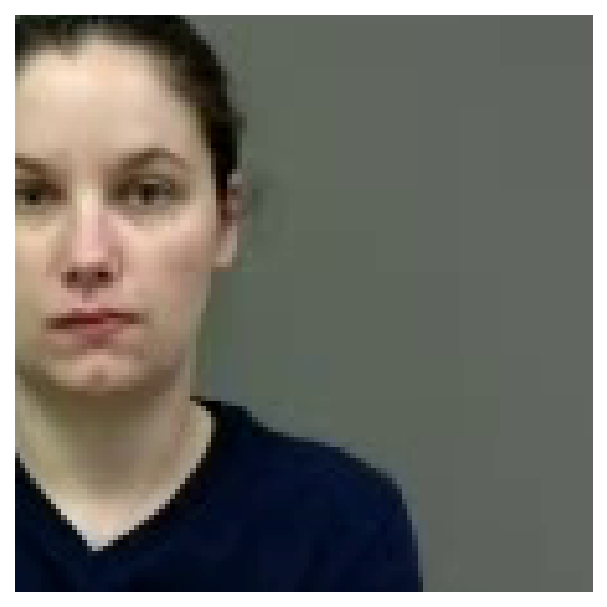

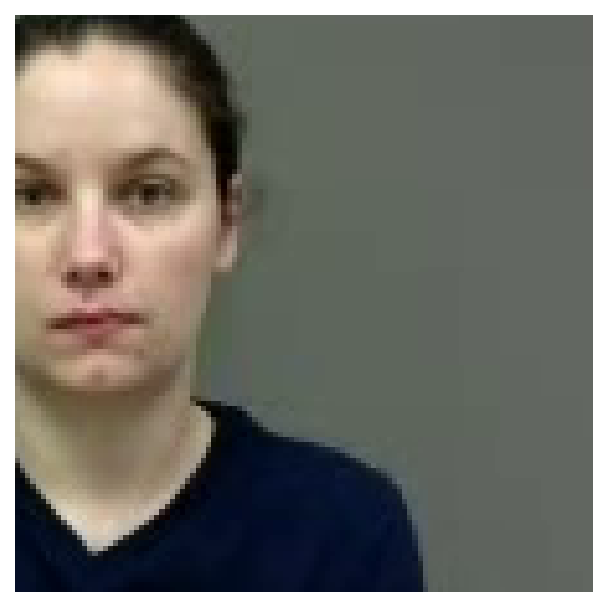

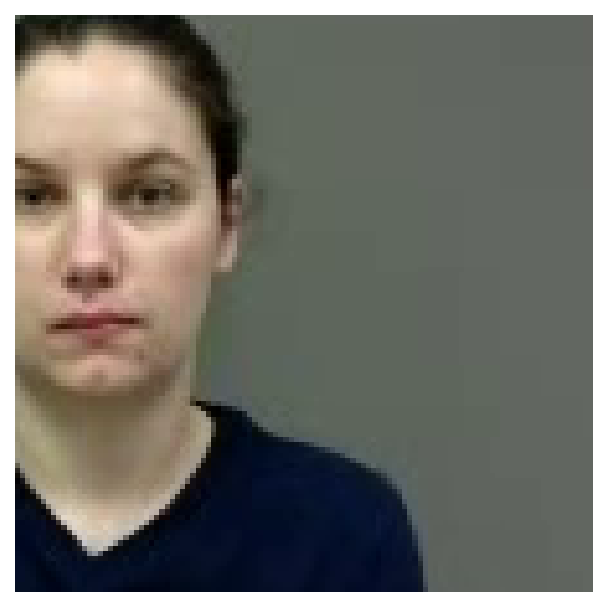

In [19]:
frames_train, label_num = prep_frames_and_label(sample_train)
print(f"frames: {frames_train.shape}")
print(f'Class: {class_list[label_num]}')
plt_display(frames_train, num_frames)

## Testing

frames: torch.Size([16, 3, 112, 112])
Class: book


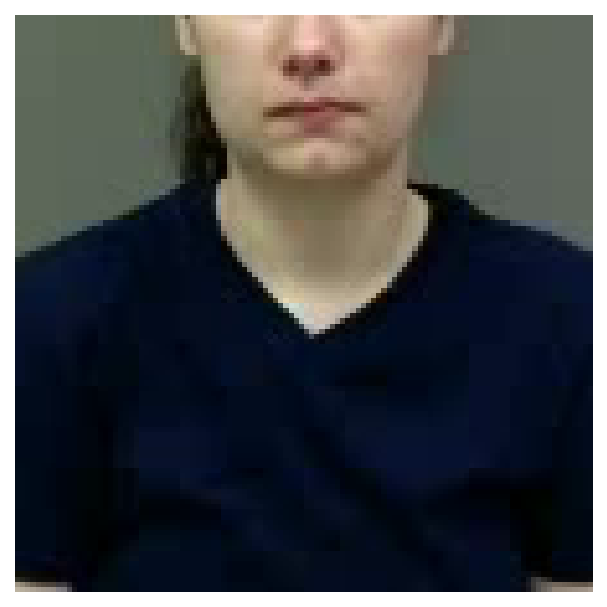

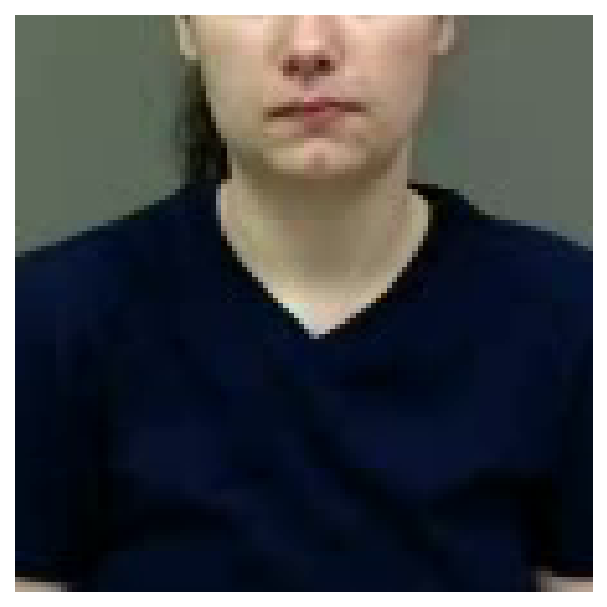

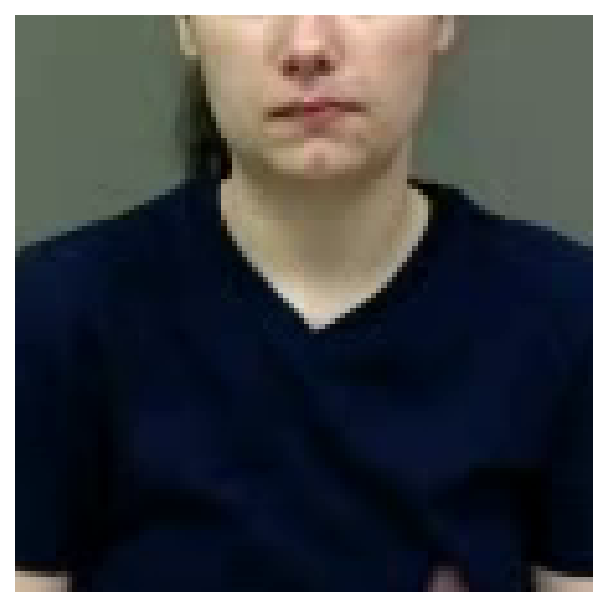

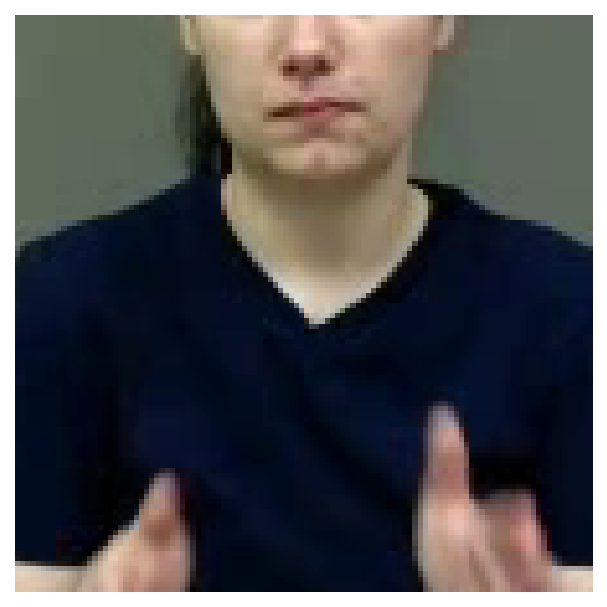

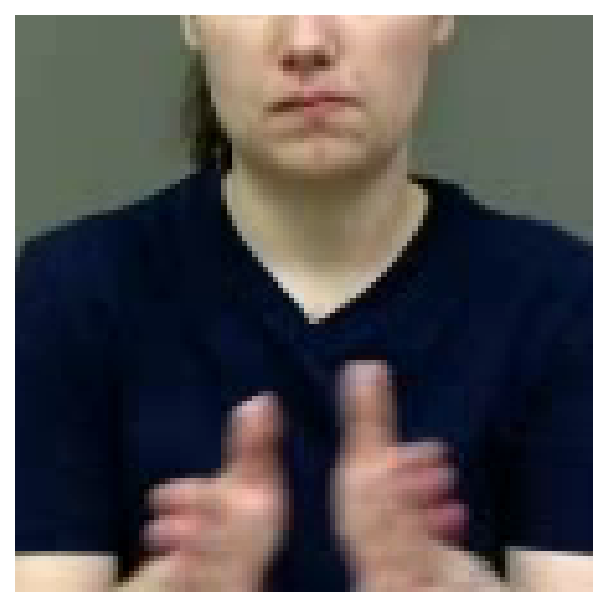

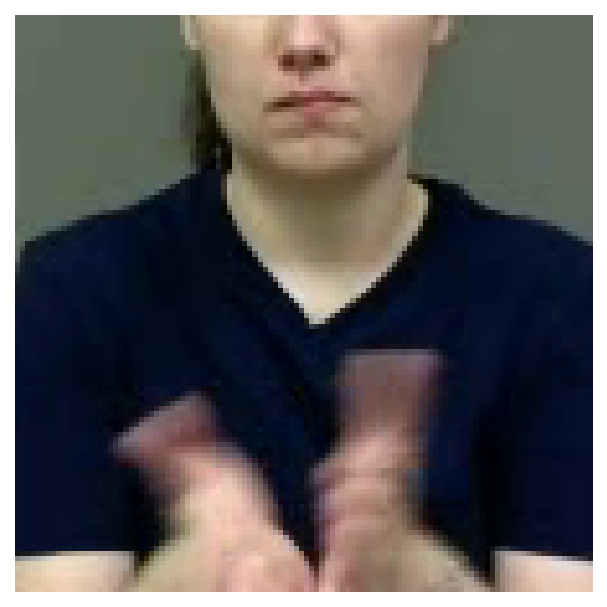

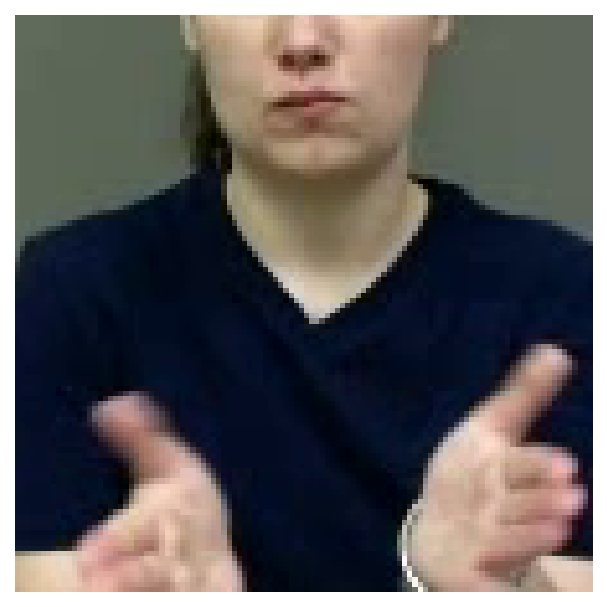

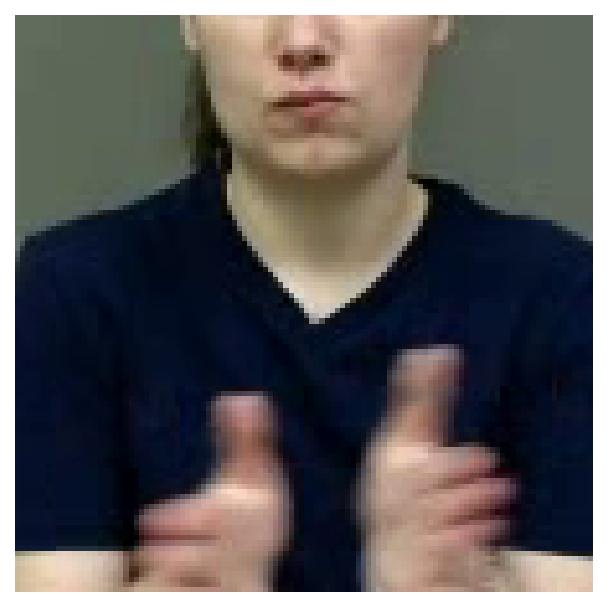

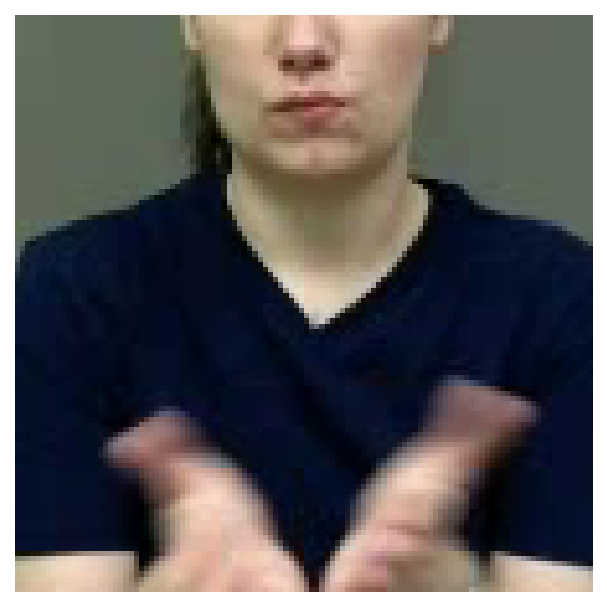

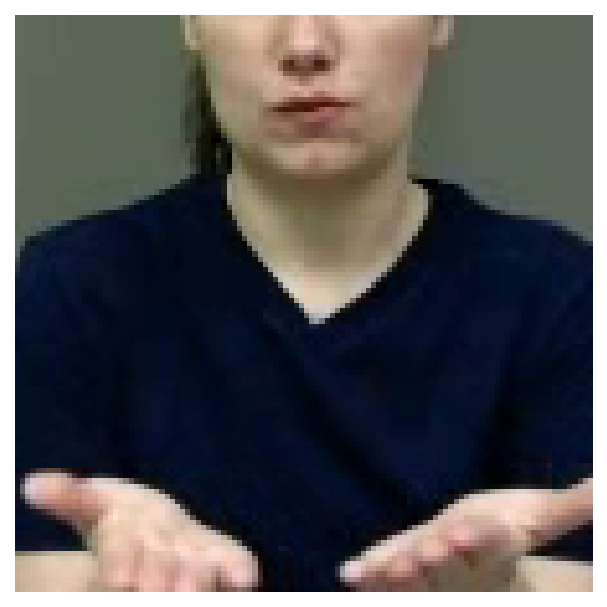

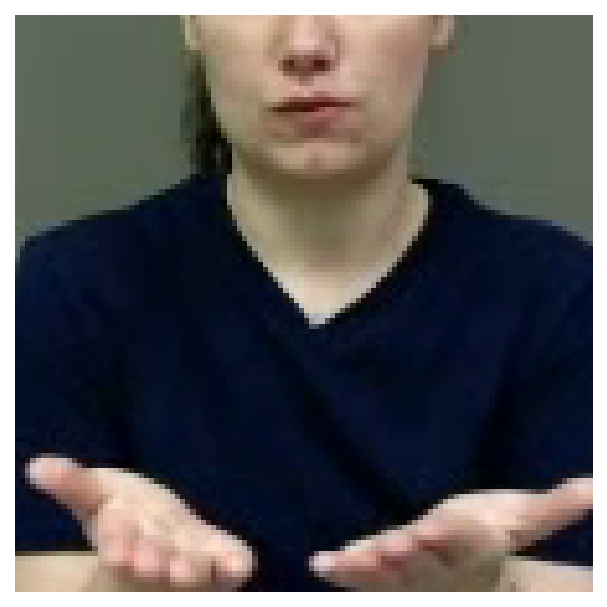

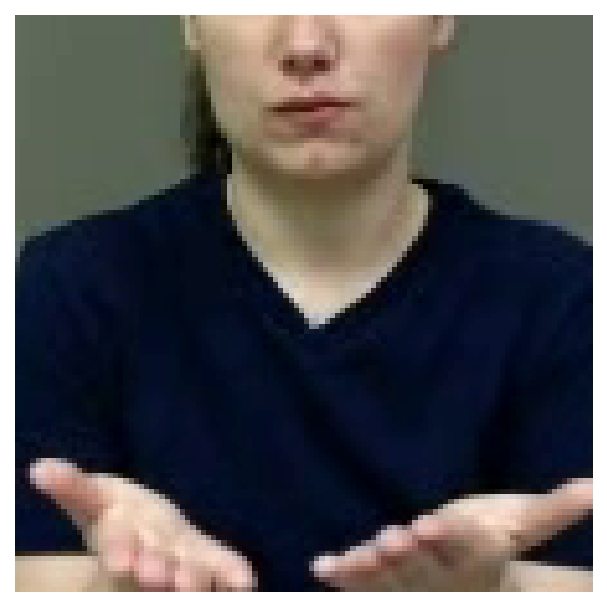

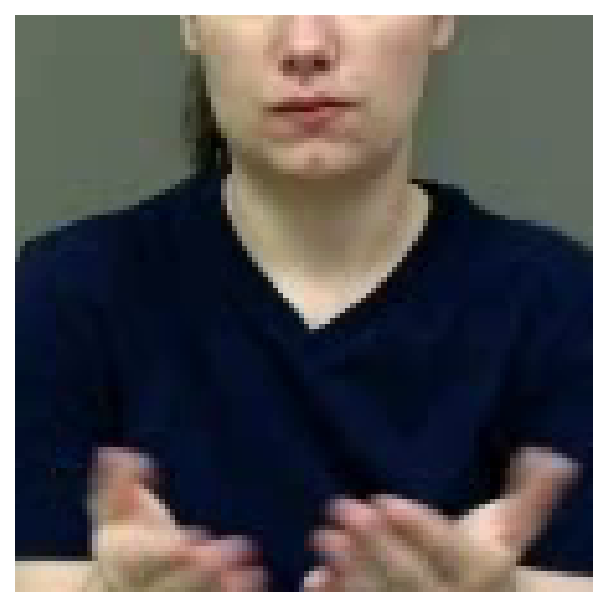

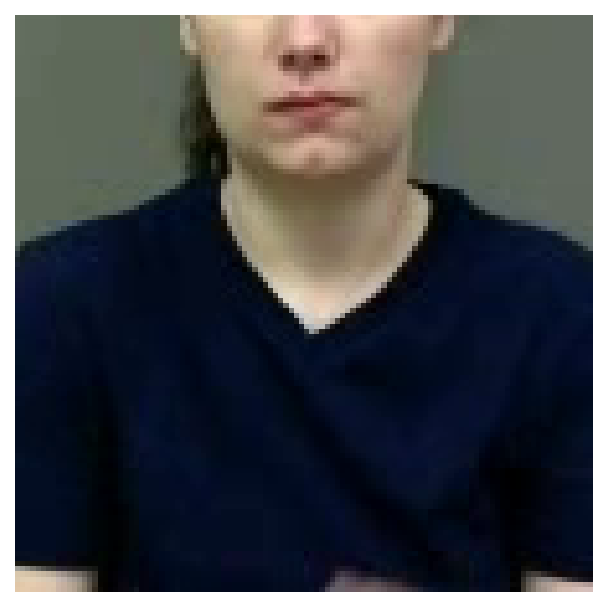

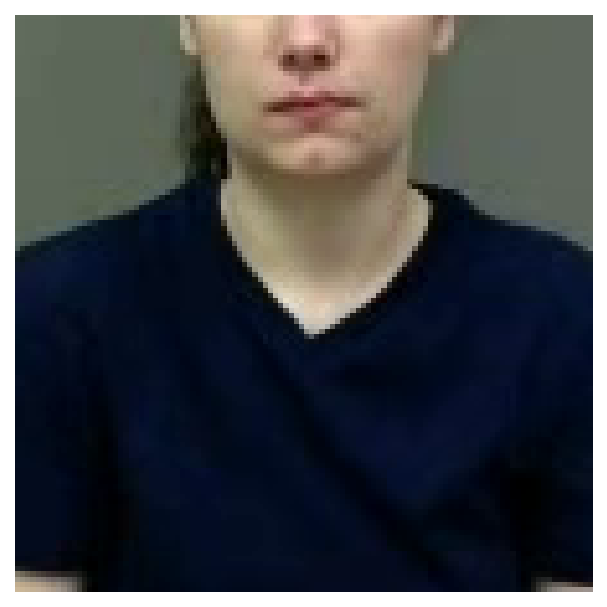

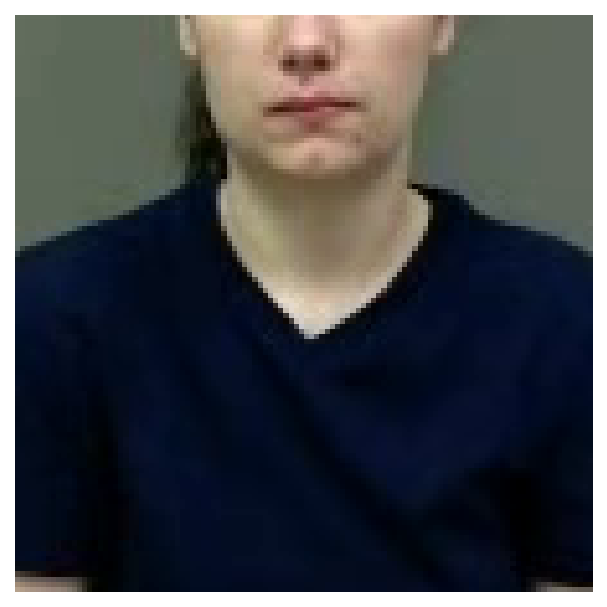

In [20]:
frames_test, label_num = prep_frames_and_label(sample_test)
print(f"frames: {frames_test.shape}")
print(f'Class: {class_list[label_num]}')
plt_display(frames_test, num_frames)

## Looking at the actual video

frames: torch.Size([63, 3, 240, 119])
Class: book


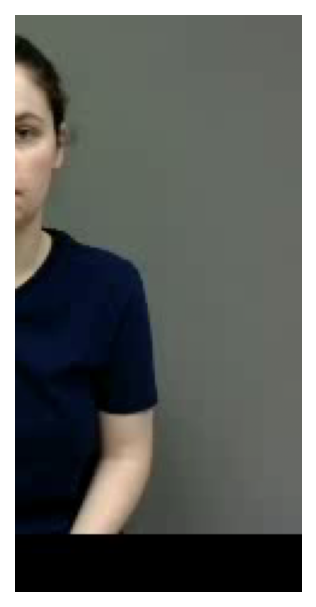

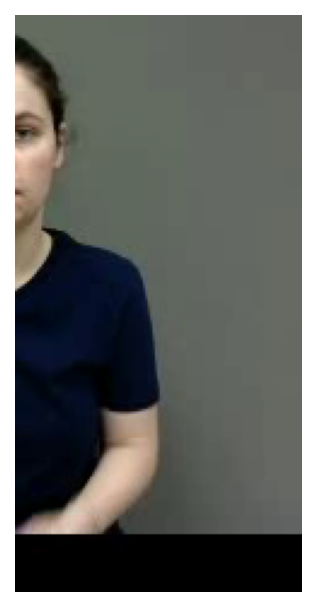

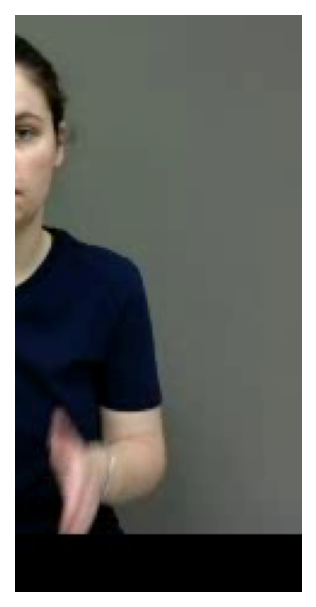

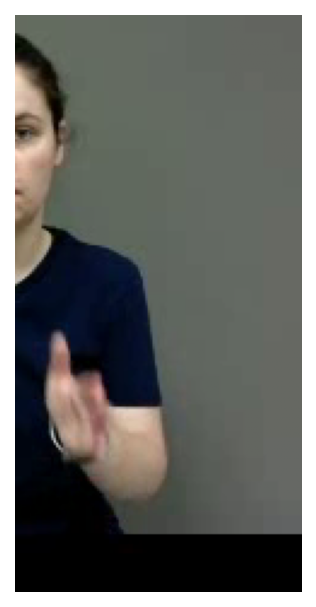

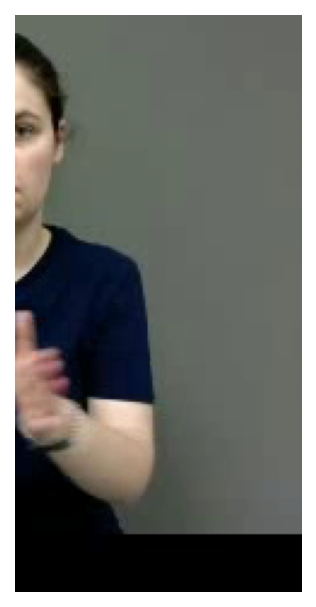

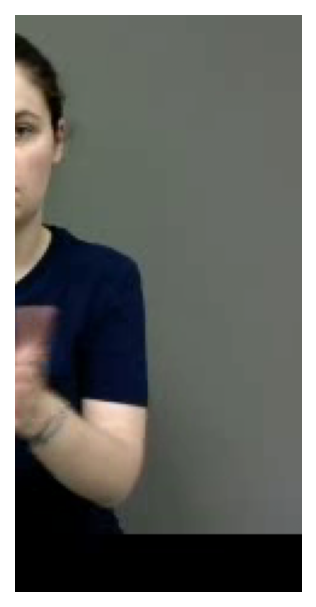

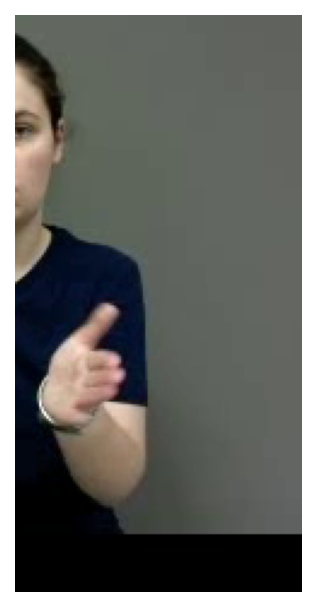

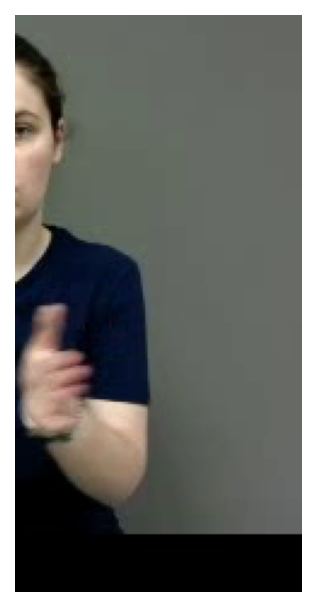

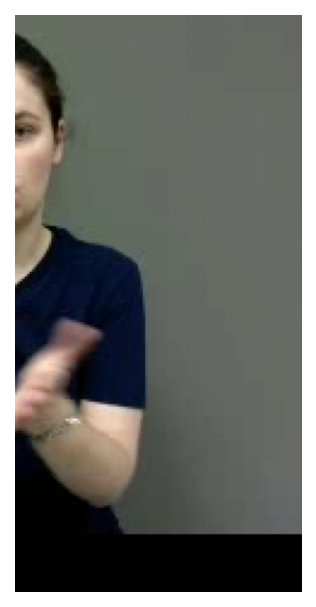

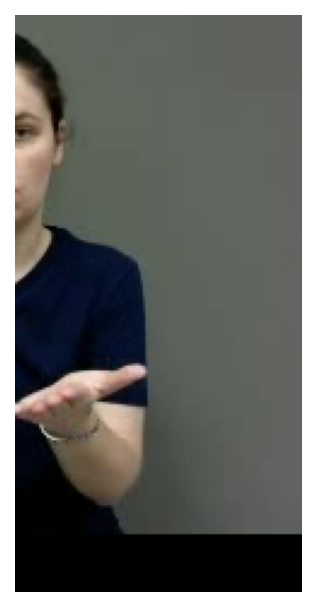

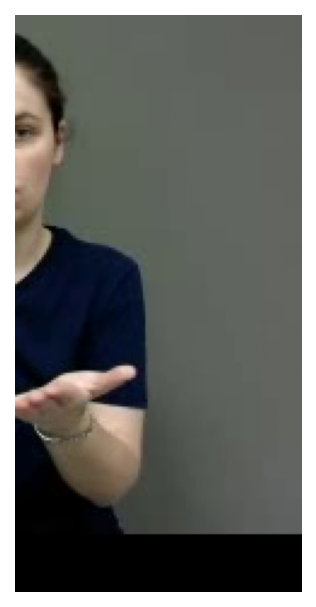

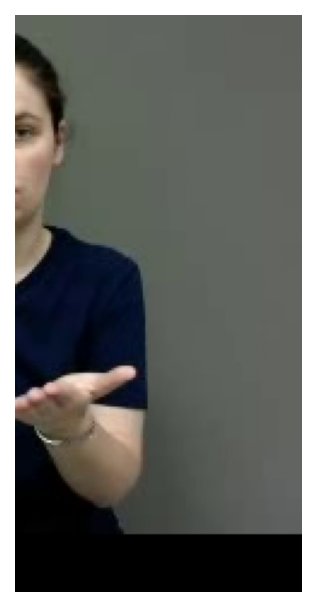

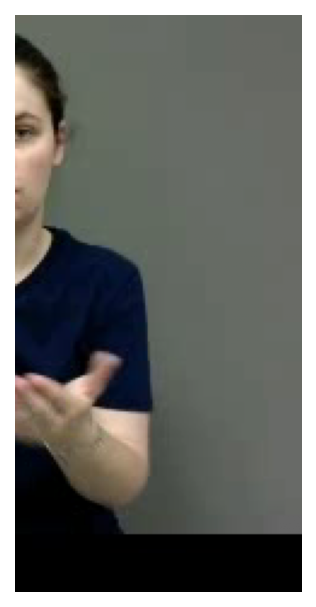

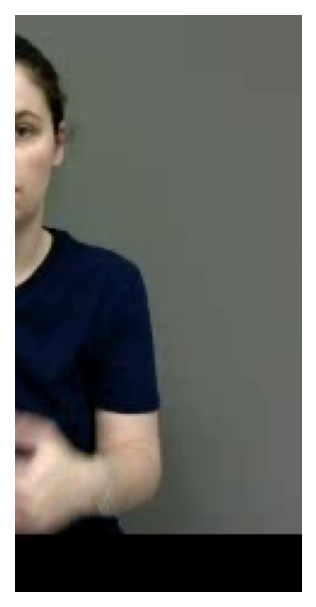

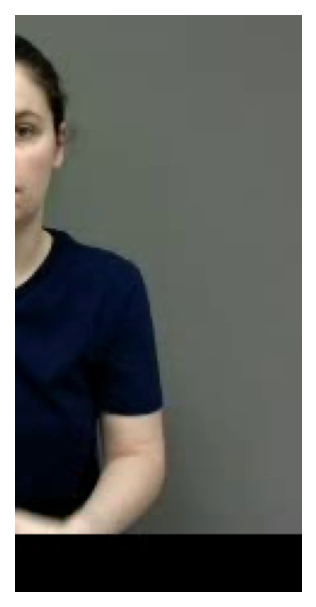

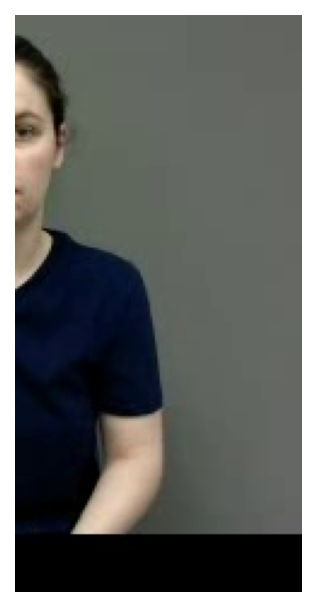

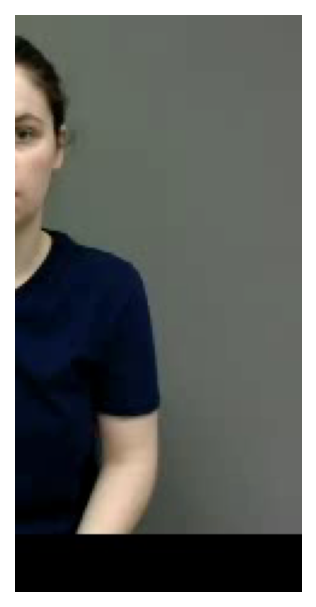

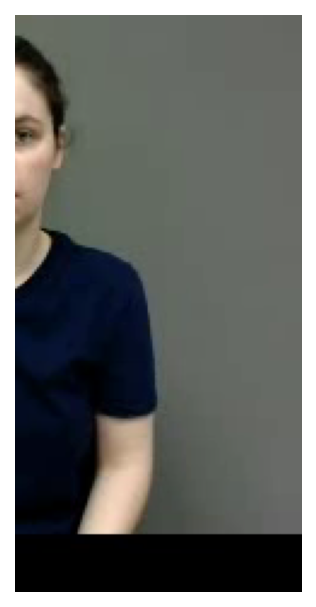

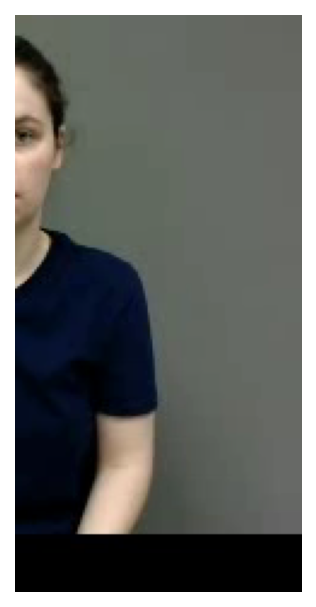

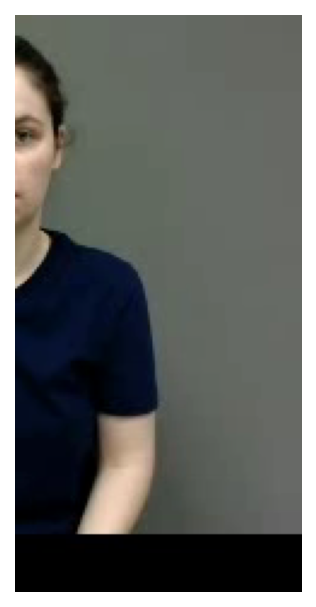

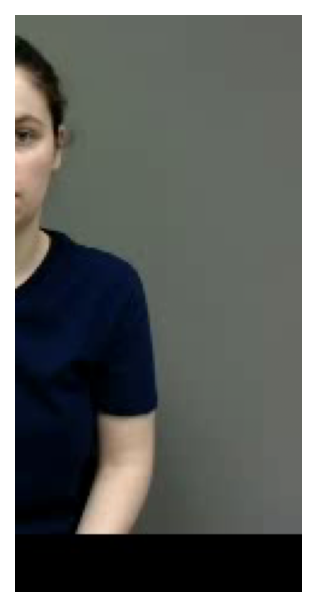

In [21]:
frames_raw, label_num = prep_frames_and_label(sample_raw)
print(f"frames: {frames_raw.shape}")
print(f'Class: {class_list[label_num]}')
plt_display(frames_raw, num_frames)

# Conclusion:

It seems that during training, significant amounts of information are being lost during cropping. Perhaps this can be remidied. Additionally, perhaps it is worth while testing with crop_bbox, instead of centre crop. 